# 01 ⋅ LLM SOTTO IL COFANO

Come genera testo un modello linguistico? In questo notebook lo scopro dal basso: carico due modelli open source piccoli (`Qwen3-0.6B` e `Qwen3-1.7B`) e osservo cosa succede a ogni passo, dal testo ai token, dai token ai punteggi (logit), dalle probabilità al token scelto. Scrivo a mano il ciclo di generazione, implemento temperatura e top-p e confronto il risultato con l'API di Gemini.

C'è anche una parte applicata, con tre esercizi pensati per il lavoro: stimare il costo di un testo in token nelle diverse lingue, classificare recensioni usando le probabilità del modello come livello di confidenza, e misurare quanto un testo sia «naturale» con la perplessità. Si chiude con un confronto tra tre modelli (tempi, token, costo) sullo stesso prompt.

- **Cosa serve:** un runtime Colab con GPU T4 e, per la parte sull'API, un secret `GEMINI_API_KEY`.
- **Limiti:** modelli piccoli, un solo prompt per il confronto finale e una sola persona che valuta le risposte. Sono esperimenti didattici, non benchmark.

**Indice**
1. Ricetta base
2. Parte 1 · Sotto il cofano: tokenizer, logit e generazione a mano
3. Parte 2 · Applicazioni pratiche: costo dei token, classificatore con confidenza, perplessità
4. Parte 3 · Decodifica e confronto con le API: temperatura, top-p, Gemini, confronto fra tre modelli
5. Appendice

## RICETTA BASE

```
model_id = "nome modello"

# 1. CARICA
tok   = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, dtype=torch.float16, device_map="cuda")

# 2. CODIFICA
inputs = tok(testo, return_tensors="pt").to(model.device)

# 3. CALCOLA (scegli cosa ti serve)
with torch.no_grad():
    out = model(**inputs)                     # out.logits, oppure out.loss se passi labels
probs = torch.softmax(out.logits[0, -1].float(), dim=-1)

# 4. GENERA (nel lavoro userò quasi sempre questa)
risposta = model.generate(**inputs, max_new_tokens=100)
print(tok.decode(risposta[0], skip_special_tokens=True))
```

## Parte 1 ⋅ Sotto il cofano

### Preparazione Colab

Installiamo le librerie necessarie e connettiamoci a T4 GPU

In [1]:
!nvidia-smi
import torch, transformers
print(torch.__version__, transformers.__version__, torch.cuda.is_available())

Fri Oct  9 07:24:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Caricare modello e tokenizer

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = "Qwen/Qwen3-0.6B"
tok = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, dtype=torch.float16, device_map="cuda")

print("Vocabolario:", len(tok), "token")
print("Parametri:", sum(p.numel() for p in model.parameters()) / 1e9, "miliardi")

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Vocabolario: 151669 token
Parametri: 0.59604992 miliardi


N.B: il model id Qwen è un LLM vero! Ciò che abbiamo fatto è stato scaricare i **pesi** ottenuti dall'addetsramento di questo modello e ciò che faremo sarà **inferenza**

Utilizziamo float16 perchè la T4 non gestisce bene il formato bfloat16.

### Ispezionare il tokenizer

In [3]:
testi = ["Ciao, mi chiamo Matteo.", "Hello, my name is Matteo.",
         "こんにちは、マッテオです。", "pallavolo", "1234567", " Matteo", "  Matteo"]
for t in testi:
    ids = tok.encode(t)
    print(f"{len(ids):2d} token | {[tok.decode([i]) for i in ids]}")

 9 token | ['C', 'iao', ',', ' mi', ' ch', 'iamo', ' Matte', 'o', '.']
 8 token | ['Hello', ',', ' my', ' name', ' is', ' Matte', 'o', '.']
 8 token | ['こんにちは', '、', 'マ', 'ッ', 'テ', 'オ', 'です', '。']
 4 token | ['p', 'all', 'av', 'olo']
 7 token | ['1', '2', '3', '4', '5', '6', '7']
 2 token | [' Matte', 'o']
 3 token | [' ', ' Matte', 'o']


- La stessa frase in italiano, inglese e giapponese richiede un numero di token pari a nove, otto e otto rispettivamente. Inglese e giapponese coincidono;
- I token del numero vengono spezzati in token corrispondenti alle singole cifre del nuemero;
- `Matteo` e  "&nbsp;&nbsp; Matteo" danno un numero di token diverso.

### Logit: i punteggi del prossimo token

Ispezioniamo i logit dell'ultimo token

In [4]:
prompt = "La capitale d'Italia è"
inputs = tok(prompt, return_tensors = "pt").to("cuda")

with torch.no_grad():
  out = model(**inputs)

print(out.logits.shape) # (batch, lunghezza sequenza, vocabolario)
last = out.logits[0, -1].float() # punteggi per il PROSSIMO token
probs = torch.softmax(last, dim=-1)

top = torch.topk(probs, 10)
for p, i in zip(top.values, top.indices):
  print(f"{tok.decode([int(i)])!r:15} {p.item():.3f}")

torch.Size([1, 7, 151936])
' la'           0.200
' il'           0.143
' un'           0.076
' l'            0.075
' in'           0.017
' a'            0.014
' una'          0.014
':\n'           0.010
' Roma'         0.009
' s'            0.009


`out.logits` ha forma `(1, 7, 151936)`: 1 testo, 7 token, un punteggio per ognuno dei 151936 indici. `len(tok)` dà 151669: la differenza è con ogni probabilità riempimento inutilizzato.
Dopo «La capitale d'Italia è» il token più probabile è ` la` (0.200), non ` Roma` (0.009): il modello sta iniziando «…è la città di Roma». La risposta non è il prossimo token, ma ciò che viene dopo.

### Generazione manuale

Costruiamo il loop autoregressivo: ogni token generato viene rimesso in input. Scelta argmax -> scelta greedy

In [5]:
ids = inputs["input_ids"]
for _ in range(15):
  with torch.no_grad():
    logits = model(input_ids = ids).logits[0,-1] # ← MODELLO: calcola i punteggi
  next_id = logits.argmax() # ← MIO CODICE: decide quale token
  ids = torch.cat([ids, next_id.view(1, 1)], dim=1) # ← MIO CODICE: lo aggiunge e ripete
print(tok.decode(ids[0]))

La capitale d'Italia è la città di Roma, ma la sua capitale è la città di Roma


Il greedy produce “…la città di Roma, ma la sua capitale è la città di Roma”: ripete sé stesso. È un difetto tipico della scelta del token più probabile a ogni passo.

OSSERVAZIONI: \
tok corrisponde al tokenizer. È un oggetto Python creato da AutoTokenizer.from_pretrained(model_id), che scarica dal repository Hugging Face alcuni file di configurazione (il vocabolario e le regole di unione del BPE). Cosa fa:
1. tok.encode("Ciao") trasforma il testo in una lista di interi, cioè gli ID dei token nel vocabolario.
2. tok.decode([id]) fa il contrario: dagli ID torna al testo.
3. tok(prompt, return_tensors="pt") fa l'encode e restituisce un dizionario con:
input_ids: gli ID, già come tensore PyTorch di forma (1, n_token) (l'1 è il "batch", cioè quante frasi elabori insieme);
attention_mask: una sequenza di 1 che dice al modello quali posizioni sono testo vero (serve quando si mettono più frasi di lunghezza diversa nello stesso batch).
len(tok) è la dimensione del vocabolario. \

Model è la rete neurale




OSSERVAZIONE 2: Ciò che abbiamo fatto è stato  prendere i pesi già addestrati dal team Qwen, congelati (per questo torch.no_grad(): niente gradienti, niente apprendimento), e usarli per calcolare la distribuzione del prossimo token su un testo nuovo.

### ESPERIMENTI: incertezza e confronto fra modelli

Racchiudiamo in una funzione il codice scritto nelle celle sopra. Aggiungimao anche **l'entropia**, che misura quanto la distribuzione dei token (output rete neurale) è 'piatta' (modello incerto) o 'concentrata' (modello sicuro).

In [6]:
def prossimo_token(prompt, mdl, tk, k=10):
  """Restituisce i k token più probabili e l'entropia della distribuzione."""
  inputs = tk(prompt, return_tensors="pt").to(mdl.device)
  with torch.no_grad():
    logits = mdl(**inputs).logits[0,-1].float()
  probs = torch.softmax(logits, dim=-1)
  entropia = -(probs * torch.log(probs + 1e-12)).sum().item()
  top = torch.topk(probs, k)
  return [(tk.decode([int(i)]), round(p.item(), 3)) for p, i in zip(top.values, top.indices)], entropia

def mostra(prompt, mdl, tk, k=5):
  top, H = prossimo_token(prompt, mdl, tk, k)
  print(f"{prompt!r} -> entropia {H:.2f}")
  for t, p in top:
    print(f"   {t!r:15} {p}")
  print()



In [7]:
prompts = [
    "The capital of Japan is",            # fattuale: risposta quasi obbligata
    "2 plus 2 is equal to",               # aritmetica
    "Ieri sera, tornando a casa, ho visto",  # creativo: molte continuazioni possibili
    "日本の首都は",                           # giapponese: "la capitale del Giappone è"
    "Il mio colore preferito è il",          # soggettivo
]

for p in prompts:
  mostra(p, model, tok)

'The capital of Japan is' -> entropia 3.15
   ' Tokyo'        0.403
   ' Kyoto'        0.166
   ' located'      0.043
   ' the'          0.032
   ' a'            0.023

'2 plus 2 is equal to' -> entropia 2.60
   ' '             0.445
   '...'           0.149
   ' what'         0.049
   '?\n\n'         0.043
   ' ...'          0.034

'Ieri sera, tornando a casa, ho visto' -> entropia 2.54
   ' un'           0.489
   ' una'          0.154
   ' che'          0.054
   ' il'           0.05
   ' a'            0.035

'日本の首都は' -> entropia 4.18
   '、'             0.53
   'どこ'            0.014
   '東'             0.009
   '，'             0.007
   '日本'            0.006

'Il mio colore preferito è il' -> entropia 3.31
   ' ros'          0.291
   ' verde'        0.097
   ' gr'           0.091
   ' bl'           0.064
   ' rosa'         0.047



Entropia bassa -> modello sicuro;
Entropia alta -> modello incerto

Un risultato che contraddice l'intuizione: il prompt «fattuale» ha entropia **più alta** del prompt «creativo» (The capital of Japan is: 3.15; Ieri sera… ho visto: 2.54). L'entropia misura l'incertezza sul *prossimo token*, non sulla verità del fatto: dopo «Japan is» sono plausibili ` Tokyo` (0.40), ` Kyoto`, ` located`, ` the`; dopo «ho visto» quasi sempre ` un` (0.49). Il giapponese ha l'entropia massima (4.18).

Carichiamo il secondo modello e confrontiamo i due:

In [8]:
model_id2 = "Qwen/Qwen3-1.7B"
tok2 = AutoTokenizer.from_pretrained(model_id2)
model2 = AutoModelForCausalLM.from_pretrained(model_id2, dtype=torch.float16, device_map="cuda")
print(f"Memoria GPU usata: {torch.cuda.memory_allocated() / 1e9:.1f} GB")


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/25.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Memoria GPU usata: 4.7 GB


In [9]:
for p in prompts:
    print("=== 0.6B ==="); mostra(p, model, tok, k=3)
    print("=== 1.7B ==="); mostra(p, model2, tok2, k=3)

=== 0.6B ===
'The capital of Japan is' -> entropia 3.15
   ' Tokyo'        0.403
   ' Kyoto'        0.166
   ' located'      0.043

=== 1.7B ===
'The capital of Japan is' -> entropia 3.02
   ' Tokyo'        0.417
   ' a'            0.071
   ' __'           0.05

=== 0.6B ===
'2 plus 2 is equal to' -> entropia 2.60
   ' '             0.445
   '...'           0.149
   ' what'         0.049

=== 1.7B ===
'2 plus 2 is equal to' -> entropia 1.89
   ' '             0.534
   ' what'         0.187
   '...'           0.053

=== 0.6B ===
'Ieri sera, tornando a casa, ho visto' -> entropia 2.54
   ' un'           0.489
   ' una'          0.154
   ' che'          0.054

=== 1.7B ===
'Ieri sera, tornando a casa, ho visto' -> entropia 2.78
   ' un'           0.388
   ' una'          0.18
   ' che'          0.073

=== 0.6B ===
'日本の首都は' -> entropia 4.18
   '、'             0.53
   'どこ'            0.014
   '東'             0.009

=== 1.7B ===
'日本の首都は' -> entropia 4.15
   '、'             0.326
   '東'      

L'1.7B ha entropia più bassa in 4 prompt su 5 (2+2: 2.60 → 1.89; colore: 3.31 → 2.37). L'eccezione è «Ieri sera… ho visto» (2.54 → 2.78): su un testo creativo più parametri non significano più certezza. Il token più probabile non cambia, tranne sul prompt soggettivo (` ros` → ` verde`).

In [10]:
for nome, m in [("0.6B", model), ("1.7B", model2)]:
    c = m.config
    n = sum(p.numel() for p in m.parameters()) / 1e9
    print(f"{nome}: {c.num_hidden_layers} strati, hidden_size {c.hidden_size}, "
          f"vocabolario {c.vocab_size}, contesto max {c.max_position_embeddings}, {n:.2f} mld parametri")

0.6B: 28 strati, hidden_size 1024, vocabolario 151936, contesto max 40960, 0.60 mld parametri
1.7B: 28 strati, hidden_size 2048, vocabolario 151936, contesto max 40960, 1.72 mld parametri


Passando da 0.6B a 1.7B restano uguali strati (28), vocabolario e contesto; raddoppia `hidden_size` (1024 → 2048) e i parametri passano da 0.60 a 1.72 miliardi, perché le matrici crescono con il quadrato della larghezza. Strati e dimensioni sono **iperparametri**, scelti prima dell'addestramento;  cambiando gli iperparametri della rete neurale, cambia di conseguenza il numero dei parametri/pesi.

## Parte 2 ⋅ Applicazioni pratiche

### 1. Stimatore di costo dei token

In generale, il costo delle API dipende dai token e i token dipendono da lingua e testo.

In [11]:
import pandas as pd

testi = {
    "italiano": "Gentile cliente, la informiamo che la fattura n. 2026/145 è in scadenza il 31 ottobre. "
                "La preghiamo di effettuare il pagamento entro tale data per evitare penali.",
    "inglese":  "Dear customer, we inform you that invoice no. 2026/145 is due on October 31. "
                "Please make the payment by that date to avoid penalties.",
    "giapponese": "お客様へ、請求書番号2026/145の支払期限は10月31日です。"
                  "延滞料を避けるため、期日までにお支払いください。",
}

def stima_costo(n_token, prezzo_per_milione):
  return (n_token / 1_000_000) * prezzo_per_milione

PREZZO_INPUT = 0.30      # $ per milione di token: valore ESEMPIO
DOCUMENTI_AL_MESE = 50_000

righe = []
for lingua, t in testi.items():
    n = len(tok.encode(t))
    righe.append({"lingua": lingua, "caratteri": len(t), "token": n,
                  "car/token": round(len(t) / n, 2),
                  "costo mensile $": round(stima_costo(n * DOCUMENTI_AL_MESE, PREZZO_INPUT), 2)})
pd.DataFrame(righe)


,lingua,caratteri,token,car/token,costo mensile $
0,italiano,162,57,2.84,0.85
1,inglese,133,38,3.50,0.57
2,giapponese,57,44,1.30,0.66


A parità di prezzo, 57 token per la frase italiana contro 38 per l'inglese: **+50%**. Il giapponese ne usa 44 (+16% sull'inglese), ma 1.30 caratteri per token contro 3.50. Limiti: le tre frasi non sono traduzioni esatte e il tokenizer è quello di Qwen, non di Gemini. La percentuale non dipende dal prezzo.

### 2. Classificatore con livello di confidenza

Casi d'uso: Smistare email, recensioni etc.

Qui usiamo il **template di chat**, cioè il formato in cui il modello è stato addestrato a conversare.

In [12]:
recensioni = [
    ("Prodotto arrivato in anticipo e funziona benissimo.", "positiva"),
    ("Si è rotto dopo due giorni, soldi buttati.", "negativa"),
    ("Assistenza clienti gentile e veloce, consigliato.", "positiva"),
    ("Imballaggio rovinato e manuale mancante.", "negativa"),
    ("Fa il suo lavoro, niente di speciale.", "positiva"),   # ambigua
    ("Bello, ma costa troppo per quello che offre.", "negativa"), # ambigua
    ("Ottimo rapporto qualità-prezzo.", "positiva"),
    ("Non lo ricomprerei.", "negativa"),
]

def classifica(testo, mdl, tk):
    messaggi = [{"role": "user", "content":
        f"Classifica la recensione come positiva o negativa. Rispondi con una sola parola.\n\nRecensione: {testo}"}]
    prompt = tk.apply_chat_template(messaggi, tokenize=False,
                                    add_generation_prompt=True, enable_thinking=False)
    inputs = tk(prompt, return_tensors="pt").to(mdl.device)
    with torch.no_grad():
        probs = torch.softmax(mdl(**inputs).logits[0, -1].float(), dim=-1)
    id_pos = tk.encode("positiva")[0]   # primo token di ciascuna etichetta
    id_neg = tk.encode("negativa")[0]
    p_pos, p_neg = probs[id_pos].item(), probs[id_neg].item()
    conf_pos = p_pos / (p_pos + p_neg)  # rinormalizzo tra le due sole opzioni
    return ("positiva" if conf_pos >= 0.5 else "negativa"), max(conf_pos, 1 - conf_pos)

SOGLIA = 0.80
risultati = []
for testo, vera in recensioni:
    pred, conf = classifica(testo, model2, tok2)
    risultati.append({"recensione": testo, "vera": vera, "predetta": pred,
                      "confidenza": round(conf, 3), "revisione umana": conf < SOGLIA})
df = pd.DataFrame(risultati)
print("Accuratezza:", (df.vera == df.predetta).mean())
df

Accuratezza: 0.875


,recensione,vera,predetta,confidenza,revisione umana
0,Prodotto arrivato in anticipo e funziona benis...,positiva,positiva,1.000,False
1,"Si è rotto dopo due giorni, soldi buttati.",negativa,negativa,1.000,False
2,"Assistenza clienti gentile e veloce, consigliato.",positiva,positiva,1.000,False
3,Imballaggio rovinato e manuale mancante.,negativa,negativa,1.000,False
4,"Fa il suo lavoro, niente di speciale.",positiva,negativa,0.987,False
5,"Bello, ma costa troppo per quello che offre.",negativa,negativa,1.000,False
6,Ottimo rapporto qualità-prezzo.,positiva,positiva,1.000,False
7,Non lo ricomprerei.,negativa,negativa,1.000,False


Proviamo con il primo modello e confrontiamo:

In [13]:
SOGLIA = 0.80
risultati = []
for testo, vera in recensioni:
    pred, conf = classifica(testo, model, tok)
    risultati.append({"recensione": testo, "vera": vera, "predetta": pred,
                      "confidenza": round(conf, 3), "revisione umana": conf < SOGLIA})
df = pd.DataFrame(risultati)
print("Accuratezza:", (df.vera == df.predetta).mean())
df

Accuratezza: 0.875


,recensione,vera,predetta,confidenza,revisione umana
0,Prodotto arrivato in anticipo e funziona benis...,positiva,positiva,0.964,False
1,"Si è rotto dopo due giorni, soldi buttati.",negativa,negativa,0.998,False
2,"Assistenza clienti gentile e veloce, consigliato.",positiva,positiva,0.954,False
3,Imballaggio rovinato e manuale mancante.,negativa,negativa,0.995,False
4,"Fa il suo lavoro, niente di speciale.",positiva,negativa,0.892,False
5,"Bello, ma costa troppo per quello che offre.",negativa,negativa,0.961,False
6,Ottimo rapporto qualità-prezzo.,positiva,positiva,0.992,False
7,Non lo ricomprerei.,negativa,negativa,0.998,False


Accuratezza 0.875 per entrambi i modelli; l'unico errore (stessa recensione) è «Fa il suo lavoro, niente di speciale», etichettata `positiva` ma discutibile: il problema può essere l'etichetta. Con soglia 0.80 nessuna recensione va in revisione umana. L'1.7B è sicuro anche quando sbaglia (confidenza 0.987); lo 0.6B dà all'errore la confidenza più bassa (0.892), per cui una soglia di 0.90 segnalerebbe solo quel caso. Le probabilità non sono confrontabili tra modelli: la soglia va scelta per ciascuno. Con 8 esempi è un indizio, non una prova.

### 3. Punteggio di naturalezza di un testo (perplessità)

In [14]:
import math

def perplessita(testo, mdl, tk):
  inputs = tk(testo, return_tensors="pt").to(mdl.device)
  with torch.no_grad():
    out = mdl(**inputs, labels=inputs["input_ids"]) # la loss è la cross-entropy media
  return math.exp(out.loss.item())

frasi = [
    "Il contratto entra in vigore dal primo gennaio 2027.",       # corretta
    "Il contratto entra in vigore dal primo genaio 2027.",        # refuso
    "Contratto il vigore primo in dal entra gennaio 2027.",       # parole mescolate
    "Il contratto entra in vigore dal primo gennaio 2O27.",       # "O" al posto di "0", tipico errore OCR
    "Il contr@tto entr4 in v1gore d4l prim0 genn41o 2027.",       # testo corrotto
]
for f in frasi:
    print(f"{perplessita(f, model2, tok2):8.1f}   {f}")

    10.0   Il contratto entra in vigore dal primo gennaio 2027.
    30.6   Il contratto entra in vigore dal primo genaio 2027.
   228.6   Contratto il vigore primo in dal entra gennaio 2027.
    28.8   Il contratto entra in vigore dal primo gennaio 2O27.
   154.3   Il contr@tto entr4 in v1gore d4l prim0 genn41o 2027.


Perplessità: corretta 10.0; refuso 30.6; «2O27» 28.8; parole mescolate 228.6; testo corrotto 154.3. Una soglia intorno a 100 separa le frasi scrambled o corrotte, ma non il refuso né l'errore OCR (circa 3× la frase corretta). Limite: la perplessità dipende dalla lunghezza e dall'argomento, quindi ha senso solo tra varianti della stessa frase.

## Parte 3 ⋅ Decodifica e confronto con le API

### Ripristino della sessione

Utilizziamo i modelli caricati al giorno A. Se la sessione è nuova, riesegui le celle di caricamento riportate di seguito:

```
!nvidia-smi
import torch, transformers
from transformers import AutoTokenizer, AutoModelForCausalLM

print(torch.__version__, transformers.__version__, torch.cuda.is_available())

model_id = "Qwen/Qwen3-0.6B"
tok = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, dtype=torch.float16, device_map="cuda")

model_id2 = "Qwen/Qwen3-1.7B"
tok2   = AutoTokenizer.from_pretrained(model_id2)
model2 = AutoModelForCausalLM.from_pretrained(model_id2, dtype=torch.float16, device_map="cuda")




Proviamo a rieseguire anche la ricetta base:

In [16]:
testo = "The highest building is"
inputs = tok(testo, return_tensors="pt").to(model.device)

# 3. CALCOLA (scegli cosa ti serve)
with torch.no_grad():
    out = model(**inputs)                     # out.logits, oppure out.loss se passi labels
probs = torch.softmax(out.logits[0, -1].float(), dim=-1)

# 4. GENERA (nel lavoro userò quasi sempre questa)
risposta = model.generate(**inputs, max_new_tokens=10)
print(tok.decode(risposta[0], skip_special_tokens=True))

The highest building is the one with the highest number of floors. So


Check:

In [17]:
print(model.device)
print(model2.device)

cuda:0
cuda:0


### Teoria: logit, temperatura, top-p

#### La catena completa
testo → token → ID → rete neurale → **logit** → **Temperatura** → top-k → **top-p** → **softmax** → estrazione.

Solo il passaggio "rete → logit" usa i parametri addestrati.
Tutto il resto è matematica esterna al modello, che decide *come* usare quei punteggi.

| Concetto | Dove agisce | Cosa fa |
|---|---|---|
| Logit | uscita della rete | punteggio grezzo per ogni token del vocabolario |
| Softmax | dopo i logit | trasforma i punteggi in probabilità |
| Temperatura | prima della softmax | cambia la "nitidezza" della distribuzione |
| Top-p | dopo la softmax | elimina la coda dei token improbabili |
| Estrazione | alla fine | sceglie un token (a caso, o `argmax` se greedy) |

###Logit

I logit sono i valori di output grezzi generati da un modello prima dell'applicazione di qualsiasi trasformazione in probabilità. Rappresentano le previsioni non normalizzate del modello per ogni possibile token in ciascuna fase della generazione del testo. Poiché tali logit non sono ancora stati trasformati in probabilità, fungono da dati di input per i metodi di campionamento che determinano quale token selezionare come parola successiva nella sequenza.

###Temperatura

DEFINIZIONE. Parametro numerico POSITIVO (T > 0) che divide i logit prima della softmax. In altri termini, prima che il modello scelga la parola (token) successiva tramite la funzione softmax, la temperatura scala i punteggi grezzi (logits).
$$p_i(T) = softmax(z_i/T)$$

EFFETTO.
- $T < 1$: le differenze tra i logit si **amplificano**, la distribuzione si concentra sui token migliori (più deterministica).
- $T = 1$: nessuna modifica, si usa la distribuzione "naturale" del modello.
- $T > 1$: le differenze si **attenuano**, la distribuzione si appiattisce e i token improbabili guadagnano peso.

CASI LIMITE.
- $T \to 0$: la distribuzione diventa un picco sul token massimo, cioè **greedy** (`argmax`).
  Il valore $T = 0$ non si può calcolare (divisione per zero): le librerie lo trattano come caso speciale.
- $T \to \infty$: distribuzione uniforme, tutti i token equiprobabili (testo senza senso).


COSA LA TEMPERATURA NON FA.
- Non cambia la conoscenza del modello né l'**ordine** dei token (il più probabile resta il più probabile).
- Non rende il modello "più creativo" in senso proprio: aumenta la probabilità di scegliere continuazioni meno probabili, che possono essere originali oppure sbagliate.
- Una temperatura bassa non elimina le allucinazioni: un modello può essere molto sicuro e sbagliato.
- Non modifica i pesi: è un parametro della decodifica, per questo è un argomento della chiamata API.


### Top-p (nucleus sampling)
ordina i token per probabilità e tiene il gruppo più piccolo che, sommato, raggiunge p:

ALGORITMO.
1. Ordina i token per probabilità decrescente.
2. Calcola la somma cumulata e tieni i primi token finché la somma raggiunge $p$ (per esempio 0,9): il **nucleo**.
3. Azzera tutti gli altri.
4. **Rinormalizza** il nucleo, in modo che la somma torni 1.
5. Estrai il token dal nucleo.

ESEMPIO. con probabilità (0,644; 0,237; 0,087; 0,032) e $p = 0{,}9$:
la cumulata è 0,644 → 0,881 → 0,968. Il terzo token fa superare 0,9, quindi si tiene, e il quarto è escluso.
Nucleo = 3 token; dopo la rinormalizzazione: 0,665; 0,245; 0,090.

DIFFERENZA CON TOP-K.
- **Top-k** tiene sempre i primi $k$ token (per esempio 50). Se il modello è sicuro (un token al 98%), ne tiene comunque 50;
  se è incerto, potrebbe tagliarne di sensati.
- **Top-p** si **adatta**: il nucleo è piccolo (anche 1-2 token) quando il modello è sicuro,
  ed è ampio quando molte continuazioni sono plausibili.

CONFRONTO CON LA TEMPERATURE.
| | Temperatura | Top-p |
|---|---|---|
| Cosa modifica | la forma di tutta la distribuzione | quali token restano possibili |
| Token eliminati | nessuno (cambiano solo i pesi) | la coda, azzerata |
| Valori tipici | 0 - 1 (fino a 2) | 0,8 - 1,0 |
| Con valore 1,0 | nessun effetto | nessun effetto (nucleo = tutti i token) |
| Caso estremo | $T\to0$: greedy | $p\to0$: tiene solo il token migliore (greedy) |



### Implementazione a mano: temperatura e top-p

In [18]:
#Temperatura:
def probs_con_temperatura(logits, T):
  return torch.softmax(logits.float() / T, dim = -1)

prompt = "Ieri sera, tornando a casa, ho visto"
inputs = tok(prompt, return_tensors="pt").to("cuda")
with torch.no_grad():
  logits = model(**inputs).logits[0, -1]

for T in [0.2, 0.7, 1.0, 1.5]:
  p = probs_con_temperatura(logits, T)
  top = torch.topk(p, 5)
  voci = [f"{tok.decode([int(i)])!r} {v:.2f}" for v, i in zip(top.values, top.indices)]
  print(f"T={T}:  " + " | ".join(voci))


T=0.2:  ' un' 1.00 | ' una' 0.00 | ' che' 0.00 | ' il' 0.00 | ' a' 0.00
T=0.7:  ' un' 0.74 | ' una' 0.14 | ' che' 0.03 | ' il' 0.03 | ' a' 0.02
T=1.0:  ' un' 0.49 | ' una' 0.15 | ' che' 0.05 | ' il' 0.05 | ' a' 0.03
T=1.5:  ' un' 0.13 | ' una' 0.06 | ' che' 0.03 | ' il' 0.03 | ' a' 0.02


Per un: T=0.2 → 1.00; 0.7 → 0.74; 1.0 → 0.49; 1.5 → 0.13. Dopo T=1 la distribuzione si appiattisce

Vediamo con un grafico

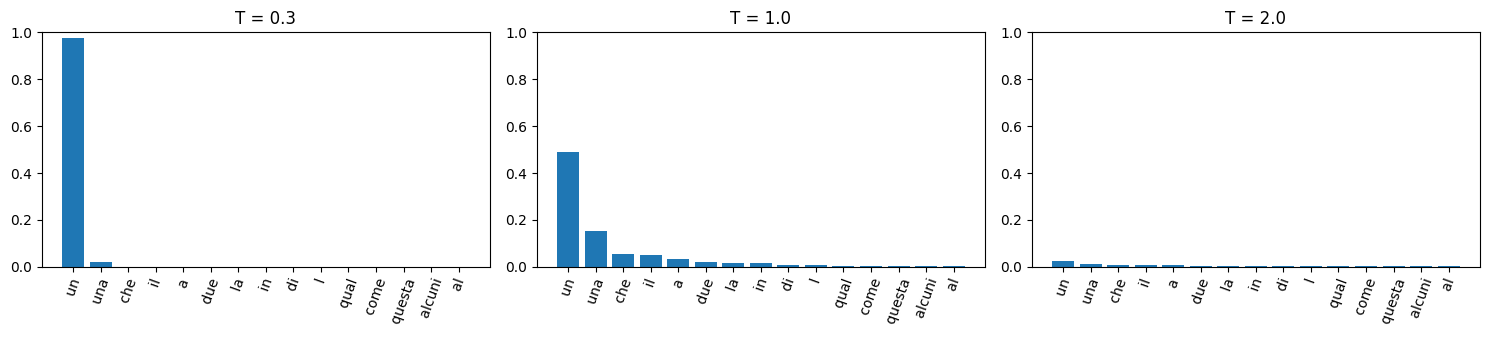

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, T in zip(axes, [0.3, 1.0, 2.0]):
    p = probs_con_temperatura(logits, T)
    top = torch.topk(p, 15)
    etichette = [tok.decode([int(i)]) for i in top.indices]
    ax.bar(range(15), top.values.cpu())
    ax.set_xticks(range(15)); ax.set_xticklabels(etichette, rotation=70)
    ax.set_title(f"T = {T}"); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

Vediamo ora il top-p

In [20]:
def filtro_top_p(probs, p):
  ordinate, indici = torch.sort(probs, descending=True)
  cumulata = torch.cumsum(ordinate, dim = -1)
  tieni = (cumulata - ordinate) < p # tiene anche il token che fa superare p
  ordinate = ordinate * tieni
  ordinate = ordinate / ordinate.sum() # rinormalizzo: somma di nuovo 1
  return torch.zeros_like(probs).scatter(0, indici, ordinate)

base = probs_con_temperatura(logits, 1.0) #T=1
for p in [0.5, 0.9, 0.99]:
    filtrate = filtro_top_p(base, p)
    print(f"top-p {p}: restano {(filtrate > 0).sum().item()} token su {len(filtrate)}")


top-p 0.5: restano 2 token su 151936
top-p 0.9: restano 29 token su 151936
top-p 0.99: restano 1318 token su 151936


Proviamo a cambiare prompt e vedere cosa succede:

In [21]:
prompt2 = "The capital city of Italy is"
inputs = tok(prompt2, return_tensors="pt").to("cuda")
with torch.no_grad():
  logits = model(**inputs).logits[0, -1]

base2 = probs_con_temperatura(logits, 1)
for p in [0.5, 0.9, 0.99]:
    filtrate = filtro_top_p(base2, p)
    print(f"top-p {p}: restano {(filtrate > 0).sum().item()} token su {len(filtrate)}")


top-p 0.5: restano 5 token su 151936
top-p 0.9: restano 197 token su 151936
top-p 0.99: restano 3754 token su 151936


Con top-p 0.9 restano 29 token per «Ieri sera… ho visto» e **197** per «The capital city of Italy is» (a 0.5: 2 contro 5; a 0.99: 1318 contro 3754). Il nucleo misura quanti token iniziali sono plausibili, non quanto il modello è sicuro del fatto.

Il ciclo di generazione completo di temperatura e top-p diventa:

In [22]:
#Ciclo di generazione COMPLETO:
def genera(prompt, mdl, tk, T=1.0, top_p=1.0, n_nuovi=30):
    ids = tk(prompt, return_tensors="pt").to(mdl.device)["input_ids"]
    for _ in range(n_nuovi):
        with torch.no_grad():
            logits = mdl(input_ids=ids).logits[0, -1]
        if T == 0:
            next_id = logits.argmax()                         # greedy
        else:
            probs = filtro_top_p(probs_con_temperatura(logits, T), top_p)
            next_id = torch.multinomial(probs, 1)[0]          # ESTRAZIONE casuale
        ids = torch.cat([ids, next_id.view(1, 1)], dim=1)
    return tk.decode(ids[0], skip_special_tokens=True)

In [23]:
#esperimento:

prompt = "Ieri sera, tornando a casa, ho visto"
for impostazione in [dict(T=0), dict(T=0.7, top_p=0.9), dict(T=1.5, top_p=1.0)]:
    print(f"\n=== {impostazione} ===")
    for _ in range(3):
        print("-", genera(prompt, model, tok, **impostazione))


=== {'T': 0} ===
- Ieri sera, tornando a casa, ho visto un cane con pelo grigio e un pelo nero. Il cane non ha un pelo nero. Certo, il cane non ha un
- Ieri sera, tornando a casa, ho visto un cane con pelo grigio e un pelo nero. Il cane non ha un pelo nero. Certo, il cane non ha un
- Ieri sera, tornando a casa, ho visto un cane con pelo grigio e un pelo nero. Il cane non ha un pelo nero. Certo, il cane non ha un

=== {'T': 0.7, 'top_p': 0.9} ===
- Ieri sera, tornando a casa, ho visto un carro parcheggiato davanti a casa. Il carro ha un carroggia, un carroggia, e un carroggia di
- Ieri sera, tornando a casa, ho visto un cane con pelo rosto, un cane con pelo rosto. La frase inizia con "Esera" e conclude con "Eser
- Ieri sera, tornando a casa, ho visto un cane con pelo nero, due anni, con un pelo nero, il pelo nero che lo aveva lasciato. Ci sono

=== {'T': 1.5, 'top_p': 1.0} ===
- Ieri sera, tornando a casa, ho visto svegli di soli Berg Units generally.


This is a homeless standalone ye

T=0: tre testi identici, anche se degenerano. Con T=0.7 e top-p 0.9: grammaticalmente corretti ma poco sensati: è un modello da 0.6B. Con T=1.5: caratteri di altre lingue e parole inventate.

Bagaglio:

- T = 0 significa niente estrazione, quindi niente casualità, quindi testi identici.
- T > 0 significa estrazione casuale; un token diverso cambia tutto il seguito, perché rientra nell'input (next_id = torch.multinomial(probs, 1)[0]).
- Il testo sconnesso nasce dalla coda di token improbabili, che su 30 passi viene pescata quasi di sicuro, e dalla propagazione dell'errore.
- Temperatura alta ingrossa la coda; top-p la taglia.

Confrontiamo ora con il generate di Hugging Face:

In [24]:
inputs = tok(prompt, return_tensors="pt").to("cuda")
out = model.generate(**inputs, max_new_tokens=30, do_sample=True, temperature=0.7, top_p=0.9)
print(tok.decode(out[0], skip_special_tokens=True))

Ieri sera, tornando a casa, ho visto una figura che non aveva né il colore di una palla da calcio, né il colore di un fucile, ma aveva un


### Gli stessi parametri via API

- Step 1: chiave nei Secrets di Colab
- Step 2: installare l'SDK e creare il client. Stiamo passando da requests a google-genai

In [25]:
!pip install -q -U google-genai

from google import genai
from google.genai import types
from google.colab import userdata

client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))
MODELLO_API = "gemini-3.5-flash-lite"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.0/268.0 kB 28.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.61.0 which is incompatible.


In [26]:
def chiedi(prompt, temperatura, top_p=0.95, modello=MODELLO_API):
    r = client.models.generate_content(
        model=modello, contents=prompt,
        config=types.GenerateContentConfig(temperature=temperatura, top_p=top_p,
                                           max_output_tokens=60))
    return r

prompt_api = "Completa con una frase sola: Ieri sera, tornando a casa, ho visto"
for T in [0.0, 1.5]:
    print(f"\n=== temperatura {T} ===")
    for _ in range(3):
        print("-", chiedi(prompt_api, T).text.strip())


=== temperatura 0.0 ===
- un gatto nero che attraversava la strada sotto la pioggia.
- un gatto nero che attraversava la strada sotto la luce fioca di un lampione.
- un gatto nero che attraversava la strada sotto la pioggia.

=== temperatura 1.5 ===
- un gatto nero che attraversava la strada sotto la pioggia.
- un gatto nero che attraversava la strada sotto la pioggia.
- Ieri sera, tornando a casa, ho visto un gatto nero che mi ha attraversato la strada portando via un topo.


A temperatura 0 due testi su tre sono identici e il terzo no: determinismo non garantito sul cloud. Anche a T = 1.5 due testi su tre sono identici: non me l'aspettavo. Ipotesi, da verificare: i modelli post-addestrati hanno distribuzioni molto concentrate sul prompt, e `top_p=0.95` taglia la coda. Da provare: 10 campioni e `top_p=1.0`.

Nota: temperatura e top_p qui sono esattamente i parametri delle mie funzioni. L'unica differenza è che il ciclo gira sui server di Google e tu ricevi solo il testo, non i logit.

In [27]:
#TOKEN USATI:
r = chiedi(prompt_api, 0.7)
u = r.usage_metadata
print("Token input:", u.prompt_token_count)
print("Token output:", u.candidates_token_count)
print("Token di ragionamento:", getattr(u, "thoughts_token_count", None))
print("Token di Qwen per lo stesso prompt:", len(tok.encode(prompt_api)))

Token input: 18
Token output: 27
Token di ragionamento: None
Token di Qwen per lo stesso prompt: 18


I token in input sono 18 sia per Gemini sia per Qwen: qui coincidono, ma non è garantito in generale. Nessun token di ragionamento (None)

### Confronto fra modelli

In [28]:
import time, pandas as pd

PROMPT = "Spiega in tre frasi a un cliente non tecnico cos'è un modello linguistico."
PREZZO_IN, PREZZO_OUT = 0.3, 2.5   # $ per milione di token: valori reali dalla pagina Pricing

def misura_locale(mdl, tk, nome):
    msg = [{"role": "user", "content": PROMPT}]
    testo = tk.apply_chat_template(msg, tokenize=False, add_generation_prompt=True, enable_thinking=False)
    inputs = tk(testo, return_tensors="pt").to(mdl.device)
    torch.cuda.synchronize(); t0 = time.perf_counter()
    out = mdl.generate(**inputs, max_new_tokens=150, do_sample=False)
    torch.cuda.synchronize(); dt = time.perf_counter() - t0
    n_in, n_out = inputs["input_ids"].shape[1], out.shape[1] - inputs["input_ids"].shape[1]
    risposta = tk.decode(out[0, n_in:], skip_special_tokens=True)
    return {"modello": nome, "secondi": round(dt, 2), "token in": n_in, "token out": n_out,
            "costo $": 0.0, "risposta": risposta}

def misura_api(nome=MODELLO_API):
    t0 = time.perf_counter()
    r = client.models.generate_content(model=nome, contents=PROMPT,
            config=types.GenerateContentConfig(temperature=0, max_output_tokens=300))
    dt = time.perf_counter() - t0
    u = r.usage_metadata
    n_in, n_out = u.prompt_token_count, (u.candidates_token_count or 0) + (getattr(u, "thoughts_token_count", 0) or 0)
    costo = n_in / 1e6 * PREZZO_IN + n_out / 1e6 * PREZZO_OUT
    return {"modello": nome, "secondi": round(dt, 2), "token in": n_in, "token out": n_out,
            "costo $": round(costo, 6), "risposta": r.text}

misura_locale(model, tok, "warmup")   # la prima esecuzione è più lenta
risultati = pd.DataFrame([misura_locale(model, tok, "Qwen3-0.6B"),
                          misura_locale(model2, tok2, "Qwen3-1.7B"),
                          misura_api()])
risultati[["modello", "secondi", "token in", "token out", "costo $"]]

,modello,secondi,token in,token out,costo $
0,Qwen3-0.6B,10.51,35,70,0.000000
1,Qwen3-1.7B,14.40,35,71,0.000000
2,gemini-3.5-flash-lite,2.02,20,93,0.000238


In [29]:
for _, riga in risultati.iterrows():
    print(f"\n=== {riga.modello} ===\n{riga.risposta}")


=== Qwen3-0.6B ===
Un modello linguistico è un sistema che interpreta e modella le regole del linguaggio per generare o analizzare parole, frasi o informazioni in modo efficiente. Questo può essere utilizzato per comprendere un linguaggio specifico, creare testi, o analizzare le relazioni grammatiche.

=== Qwen3-1.7B ===
Un modello linguistico è un programma che impara a comprendere e generare testo, come un uomo che impara a parlare. È un computer che cerca di capire cosa si dice e di rispondere in modo corretto. È come un insegnante che insegni a un bambino a parlare.

=== gemini-3.5-flash-lite ===
Un modello linguistico è un programma informatico avanzato che è stato addestrato leggendo un'enorme quantità di testi umani per capire come funziona il linguaggio. Grazie a questo apprendimento, è in grado di comprendere le nostre richieste e generare risposte in linguaggio naturale, proprio come farebbe una persona. In pratica, è come un assistente virtuale molto intelligente che sa con

Per un'applicazione che risponde a 10.000 clienti al giorno sceglierei gemini-3.5-flash-lite perché in questo test dà la risposta migliore per qualità e chiarezza, è circa 5-7 volte più veloce (2 s contro 10-14 s) e costa circa $0,00024 a richiesta, cioè circa 72 dollari (cost * 10.000 * 30) al mese a prezzo pieno. Il modello locale costerebbe zero in licenze, ma richiede una GPU dedicata, un lavoro di gestione e dà risposte di qualità inferiore.

## Appendice:

Esempio di codice con ricetta base eseguito con il modello "Qwen/Qwen3-1.7B"

In [31]:
'''
# 1. CARICA
tok2   = AutoTokenizer.from_pretrained(model_id2)
model2 = AutoModelForCausalLM.from_pretrained(model_id2, dtype=torch.float16, device_map="cuda")
'''

# 2. CODIFICA
testo = "The capital city of Italy is"
inputs = tok2(testo, return_tensors="pt").to(model2.device)

# 3. CALCOLA (scegli cosa ti serve)
with torch.no_grad():
    out = model2(**inputs)                     # out.logits, oppure out.loss se passi labels
probs = torch.softmax(out.logits[0, -1].float(), dim=-1)

# 4. GENERA (nel lavoro userai quasi sempre questa)
risposta = model2.generate(**inputs, max_new_tokens=100)
print(tok2.decode(risposta[0], skip_special_tokens=True))

The capital city of Italy is Rome. The capital city of Italy is Rome. The capital city of Italy is Rome. The capital city of Italy is Rome. The capital city of Italy is Rome. The capital city of Italy is Rome. The capital city of Italy is Rome. The capital city of Italy is Rome. The capital city of Italy is Rome. The capital city of Italy is Rome. The capital city of Italy is Rome. The capital city of Italy is Rome. The capital city of Italy is Rome. The capital
